<a href="https://colab.research.google.com/github/nabinjoshi54/lis5693/blob/main/lab-5/Lab_5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For this lab-5 work, I will focus on Topic modeling.
First of all, I will install the necessary packages. This lab will use gensim for LDA topic modeling, nltk for stopwords, pandas for data handling, and pyLDAvis for topic visualization.

Here I import the libraries needed.

In [ ]:
!pip install gensim pyLDAvis nltk pandas matplotlib -q

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
pyLDAvis.enable_notebook()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 39.1 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Task1: Dataset description:
For this lab, I selected a bibliographic dataset from the link you provided (https://www.lens.org/lens/search/scholar/) focused on Battery AND Space. I chose this topic because this is what I do for my own research and aligns with my acadenic interest in energy systems. I exported metadata for 1000 articles from the website (https://www.lens.org/lens/search/scholar/list?q=battery%20AND%20space&p=0&n=10&s=_score&d=%2B&f=false&e=false&l=en&authorField=author&dateFilterField=publishedYear&orderBy=%2B_score&presentation=false&preview=true&stemmed=true&useAuthorId=false).

The dataset includes metadata such as titles, abstracts, authors, and publication information. For topic modeling, I selected the abstract column because it provides richer and more detailed textual content than titles alone, making it more suitable for discovering meaningful topics.
The data is uploaded into my lab-5 folder in github and will be loaded directly in github.

In [ ]:
import pandas as pd
import requests
import io

# Replace this with your own raw GitHub CSV link
url = "https://raw.githubusercontent.com/nabinjoshi54/lis5693/refs/heads/main/lab-5/lab5-batteries-and-space.csv"

response = requests.get(url)
response.raise_for_status()

df = pd.read_csv(io.StringIO(response.text))
print("Dataset shape:", df.shape)
df.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Dataset shape: (1000, 32)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Lens ID,Title,Date Published,Publication Year,Publication Type,Source Title,ISSNs,Publisher,Source Country,Author/s,...,PMID,DOI,Microsoft Academic ID,PMCID,Citing Patents Count,References,Citing Works Count,Is Open Access,Open Access License,Open Access Colour
0,000-277-169-899-878,WATER-ACTIVATED DRY-CHARGED LEAD–ACID BATTERIES,NaN,1970.0,book chapter,Research and Development in Non-Mechanical Ele...,NaN,Elsevier,NaN,D.L. Douglas; R.E. Biddick; J.B. Ockerman,...,NaN,10.1016/b978-0-08-013435-2.50011-6,2234449575,NaN,0,026-727-716-648-058; 118-148-506-040-617,3,False,NaN,NaN
1,000-296-458-948-553,Digitally controlled autonomous Li-ion active ...,NaN,2014.0,conference proceedings article,2014 International Conference on Advances in E...,NaN,IEEE,NaN,G Rishivathsala; S Ananda; V. Sreekumar; Nitin...,...,NaN,10.1109/icaecc.2014.7002466,2541639867,NaN,0,029-655-612-502-395; 066-402-048-809-762; 073-...,4,False,NaN,NaN
2,000-395-893-043-269,Space systems � Lithium ion battery for space ...,2016-03-19,2016.0,standard,NaN,NaN,BSI British Standards,NaN,NaN,...,NaN,10.3403/30296384u,NaN,NaN,0,NaN,0,False,NaN,NaN
3,000-550-445-902-514,Cost-Benefit Analysis Model of Single and Hybr...,NaN,2014.0,journal article,Applied Mechanics and Materials,16627482,"Trans Tech Publications, Ltd.",NaN,Yi Feng; Lei Jun Shao; Bang Ling Zhang; Jing Y...,...,NaN,10.4028/www.scientific.net/amm.672-674.503,1999071943,NaN,0,053-147-224-892-52X; 066-432-448-842-155; 095-...,0,False,NaN,NaN
4,000-621-072-737-768,The 2000 NASA Aerospace Battery Workshop,2001-03-01,2001.0,NaN,NaN,NaN,NaN,NaN,Jeffrey C. Brewer,...,NaN,NaN,2801440225,NaN,0,NaN,0,False,NaN,NaN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Task2: In this task, I display first 10 rows of dataset and try to understand its structure to identify which column would  be most suitable for topic modeling.

To run topic modeling, I need a text based column that contains meaningful article content such as title, abstract, keyword or publication title.

For text column, I am selecting abstract column becasue it provides the most complete summary of each article's content, has rich vocabulary and more context as compared to mere titles.  

In [ ]:
df.head(10)
print(df.columns.tolist())

# Try to automatically find a likely text column
possible_cols = [c for c in df.columns if 'abstract' in c.lower() or 'description' in c.lower() or 'title' in c.lower()]
print("Possible text columns:", possible_cols)

# Replace this with your actual chosen column name if needed
text_col = possible_cols[0] if possible_cols else df.columns[0]
print("Selected text column:", text_col)

docs = df[text_col].dropna().astype(str).tolist()
print("Number of usable documents:", len(docs))
print("\nSample document:\n")
print(docs[0][:1000])



['Lens ID', 'Title', 'Date Published', 'Publication Year', 'Publication Type', 'Source Title', 'ISSNs', 'Publisher', 'Source Country', 'Author/s', 'Abstract', 'Volume', 'Issue Number', 'Start Page', 'End Page', 'Fields of Study', 'Keywords', 'MeSH Terms', 'Chemicals', 'Funding', 'Source URLs', 'External URL', 'PMID', 'DOI', 'Microsoft Academic ID', 'PMCID', 'Citing Patents Count', 'References', 'Citing Works Count', 'Is Open Access', 'Open Access License', 'Open Access Colour']
Possible text columns: ['Title', 'Source Title', 'Abstract']
Selected text column: Title
Number of usable documents: 1000

Sample document:

WATER-ACTIVATED DRY-CHARGED LEAD–ACID BATTERIES


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Task3: In this cell, I will focus on preprocessing the text. I clean the text by converting it into lowercase, removing punctuation, removing standalone numbers, and filtering out the stopwords such as study, method, results, which are frequently used in academic writing but do not contribute meaningfully. I also remove short tokens and add some custom stopwords that are too common to be useful for interpreting topics.

In [ ]:
stop_words = set(stopwords.words("english"))

custom_stopwords = {
    "et", "al", "using", "used", "use", "based", "study", "results",
    "method", "methods", "analysis", "research", "paper", "article",
    "also", "within", "however", "can", "may", "one", "two", "new",
    "show", "shown", "different"
}

stop_words = stop_words.union(custom_stopwords)



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def clean_doc(doc):
    doc = doc.lower()
    doc = re.sub(r"\d+", " ", doc)                 # remove numbers
    doc = re.sub(rf"[{re.escape(string.punctuation)}]", " ", doc)  # remove punctuation
    doc = re.sub(r"\s+", " ", doc).strip()         # normalize spaces

    tokens = doc.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2 and w.isalpha()]
    return tokens

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
cleaned_docs = [clean_doc(doc) for doc in docs]

cleaned_docs = [doc for doc in cleaned_docs if len(doc) > 0]
print("Documents after cleaning:", len(cleaned_docs))



Documents after cleaning: 1000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

After preprocessing, I removed any empty documents created during cleaning. This helps improve topic quality by ensuring that the LDA model is trained only on documents containing meaningful text.

In [ ]:
print("Original document sample:\n")
print(docs[0][:500])

print("\nCleaned document sample:\n")
print(cleaned_docs[0][:50])

Original document sample:

WATER-ACTIVATED DRY-CHARGED LEAD–ACID BATTERIES

Cleaned document sample:

['water', 'activated', 'dry', 'charged', 'batteries']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Now, after text preprocessing, I am converting the cleaned documents into a dictionary and bag of words corpus, which are requried inputs for LDA topic modeling.

In [ ]:
dictionary = corpora.Dictionary(cleaned_docs)

# Optional filtering to improve topic quality
dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus = [dictionary.doc2bow(doc) for doc in cleaned_docs]

print("Number of unique tokens:", len(dictionary))
print("Number of documents:", len(corpus))

Number of unique tokens: 241
Number of documents: 1000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Here, I first train an LDA model with 5 topics and inspect the top 5 words for each topic

In [ ]:
lda_5 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

print("Top 5 words for each topic in the 5-topic model:\n")
for idx, topic in lda_5.print_topics(num_words=5):
    print(f"Topic {idx}: {topic}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Top 5 words for each topic in the 5-topic model:

Topic 0: 0.107*"nickel" + 0.074*"space" + 0.067*"hydrogen" + 0.053*"performance" + 0.048*"batteries"
Topic 1: 0.130*"space" + 0.100*"batteries" + 0.050*"ion" + 0.042*"lithium" + 0.039*"applications"
Topic 2: 0.076*"space" + 0.064*"state" + 0.062*"batteries" + 0.046*"lithium" + 0.042*"ion"
Topic 3: 0.075*"system" + 0.056*"space" + 0.049*"development" + 0.041*"management" + 0.037*"power"
Topic 4: 0.089*"lithium" + 0.086*"ion" + 0.058*"batteries" + 0.055*"space" + 0.050*"power"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

After lda_5, I train an LDA model with 10 topics and inspect the top 5 words for each topic.

In [ ]:
lda_10 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

print("Top 5 words for each topic in the 10-topic model:\n")
for idx, topic in lda_10.print_topics(num_words=5):
    print(f"Topic {idx}: {topic}")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Top 5 words for each topic in the 10-topic model:

Topic 0: 0.119*"nickel" + 0.085*"space" + 0.079*"hydrogen" + 0.059*"batteries" + 0.058*"performance"
Topic 1: 0.175*"space" + 0.111*"batteries" + 0.053*"applications" + 0.034*"application" + 0.026*"technology"
Topic 2: 0.108*"state" + 0.064*"charge" + 0.064*"model" + 0.063*"batteries" + 0.062*"space"
Topic 3: 0.090*"space" + 0.058*"vehicle" + 0.042*"development" + 0.036*"power" + 0.036*"system"
Topic 4: 0.068*"lithium" + 0.056*"space" + 0.056*"systems" + 0.055*"batteries" + 0.053*"ion"
Topic 5: 0.135*"power" + 0.091*"system" + 0.088*"space" + 0.054*"batteries" + 0.048*"thermal"
Topic 6: 0.063*"ion" + 0.052*"lithium" + 0.052*"charger" + 0.045*"spacecraft" + 0.029*"system"
Topic 7: 0.105*"system" + 0.084*"management" + 0.060*"sub" + 0.030*"data" + 0.030*"design"
Topic 8: 0.162*"ion" + 0.150*"lithium" + 0.103*"batteries" + 0.060*"space" + 0.030*"cells"
Topic 9: 0.110*"nasa" + 0.098*"space" + 0.091*"flight" + 0.067*"aerospace" + 0.065*"wor

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

I also train a 15-topic model and inspect top 5 words for each topic.

In [ ]:
lda_15 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=15,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

print("Top 5 words for each topic in the 15-topic model:\n")
for idx, topic in lda_15.print_topics(num_words=5):
    print(f"Topic {idx}: {topic}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Top 5 words for each topic in the 15-topic model:

Topic 0: 0.115*"performance" + 0.080*"orbit" + 0.057*"space" + 0.051*"nickel" + 0.049*"hubble"
Topic 1: 0.190*"space" + 0.120*"batteries" + 0.101*"applications" + 0.055*"power" + 0.049*"systems"
Topic 2: 0.126*"state" + 0.086*"space" + 0.083*"model" + 0.073*"ion" + 0.070*"lithium"
Topic 3: 0.111*"space" + 0.081*"technology" + 0.070*"batteries" + 0.061*"lithium" + 0.042*"ion"
Topic 4: 0.108*"lithium" + 0.095*"satellite" + 0.087*"ion" + 0.075*"space" + 0.072*"cells"
Topic 5: 0.136*"thermal" + 0.079*"space" + 0.068*"batteries" + 0.039*"development" + 0.038*"power"
Topic 6: 0.077*"high" + 0.057*"power" + 0.054*"charger" + 0.053*"application" + 0.051*"voltage"
Topic 7: 0.106*"management" + 0.068*"sub" + 0.061*"system" + 0.045*"review" + 0.040*"batteries"
Topic 8: 0.134*"lithium" + 0.120*"ion" + 0.091*"batteries" + 0.063*"aerospace" + 0.041*"cell"
Topic 9: 0.099*"space" + 0.093*"flight" + 0.081*"center" + 0.061*"goddard" + 0.053*"nasa"
Topic

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In this case, I train a fourth LDA model with 20 topics and compare its interpretability with the 5, 10, 15-topic model.  This is the lab assignment requirement.

In [ ]:
lda_20 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=20,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

print("Top 5 words for each topic in the 20-topic model:\n")
for idx, topic in lda_20.print_topics(num_words=5):
    print(f"Topic {idx}: {topic}")



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Top 5 words for each topic in the 20-topic model:

Topic 0: 0.115*"space" + 0.098*"telescope" + 0.096*"performance" + 0.092*"hubble" + 0.055*"nickel"
Topic 1: 0.130*"space" + 0.101*"ion" + 0.070*"lithium" + 0.065*"application" + 0.057*"batteries"
Topic 2: 0.169*"state" + 0.082*"space" + 0.079*"lithium" + 0.075*"ion" + 0.074*"batteries"
Topic 3: 0.174*"development" + 0.167*"space" + 0.094*"technology" + 0.052*"power" + 0.043*"exploration"
Topic 4: 0.193*"systems" + 0.111*"space" + 0.075*"lithium" + 0.067*"power" + 0.067*"safety"
Topic 5: 0.095*"system" + 0.094*"testing" + 0.062*"batteries" + 0.052*"power" + 0.050*"thermal"
Topic 6: 0.127*"charger" + 0.079*"integrated" + 0.077*"control" + 0.051*"phase" + 0.044*"subsystem"
Topic 7: 0.221*"nickel" + 0.125*"hydrogen" + 0.095*"cadmium" + 0.076*"management" + 0.057*"test"
Topic 8: 0.216*"ion" + 0.203*"lithium" + 0.101*"batteries" + 0.061*"space" + 0.040*"polymer"
Topic 9: 0.146*"nasa" + 0.129*"flight" + 0.110*"space" + 0.095*"aerospace" + 0.0

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Comparing the Topic Quality:
To compare the topic models more systematically, I calculate coherence scores for each topic models. Higher coherence generally indicates more interpretable topics.

In [ ]:
coherence_5 = CoherenceModel(model=lda_5, texts=cleaned_docs, dictionary=dictionary, coherence='c_v')
coherence_score_5 = coherence_5.get_coherence()

coherence_10 = CoherenceModel(model=lda_10, texts=cleaned_docs, dictionary=dictionary, coherence='c_v')
coherence_score_10 = coherence_10.get_coherence()

coherence_15 = CoherenceModel(model=lda_15, texts=cleaned_docs, dictionary=dictionary, coherence='c_v')
coherence_score_15 = coherence_15.get_coherence()

coherence_20 = CoherenceModel(model=lda_20, texts=cleaned_docs, dictionary=dictionary, coherence='c_v')
coherence_score_20 = coherence_20.get_coherence()

print("Coherence score (5 topics):", coherence_score_5)
print("Coherence score (10 topics):", coherence_score_10)
print("Coherence score (15 topics):", coherence_score_15)
print("Coherence score (20 topics):", coherence_score_20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Coherence score (5 topics): 0.3106107311292771
Coherence score (10 topics): 0.3535119748908668
Coherence score (15 topics): 0.3795810044908237
Coherence score (20 topics): 0.41007949665364707


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Model Selection:

Based on the coherence scores and the interpretability of the topic keywords, I selected the model that provides the most meaningful and distinct topics.

I trained four LDA models with 5, 10, 15, and 20 topics and compared their outputs using coherence scores and topic interpretability.

The coherence score increased as the number of topics increased, with the 20-topic model achieving the highest score. This suggests that the 20-topic model captures the most meaningful structure in the dataset. The 20-topic model produced broader and more general themes.

Although the 20-topic model includes some overlap among related themes, it provides the most detailed and coherent representation of the dataset. Therefore, I selected the 20-topic model as the best model for this analysis.

Task4: Visualizing the topic resuls.
The 5-topic model produces broad themes, while the 10- and 15-topic models provide clearer separation of subthemes. The 20-topic model is the most detailed and has the highest coherence score, although some related topics overlap.

The bar chart below summarizes the coherence scores for the four models.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

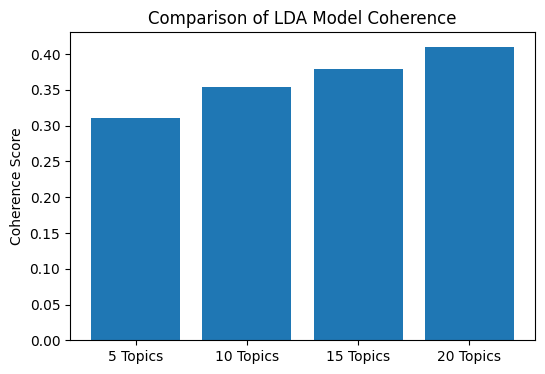

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Plotting the coherence scores

models = ["5 Topics", "10 Topics", "15 Topics", "20 Topics"]
scores = [coherence_score_5, coherence_score_10, coherence_score_15, coherence_score_20]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.ylabel("Coherence Score")
plt.title("Comparison of LDA Model Coherence")
plt.show()

Top 5 Words for Each Topic:
Below, I print the top 5 words for each topic in the 5-, 10-, 15-, and 20-topic models. These keywords help identify the main theme represented by each topic.

In [ ]:
def print_topics(model, num_words=5):
    for idx, topic in model.print_topics(num_words=num_words):
        print(f"Topic {idx}: {topic}")

print("\n===== 5 TOPICS =====")
print_topics(lda_5)

print("\n===== 10 TOPICS =====")
print_topics(lda_10)

print("\n===== 15 TOPICS =====")
print_topics(lda_15)

print("\n===== 20 TOPICS =====")
print_topics(lda_20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


===== 5 TOPICS =====
Topic 0: 0.107*"nickel" + 0.074*"space" + 0.067*"hydrogen" + 0.053*"performance" + 0.048*"batteries"
Topic 1: 0.130*"space" + 0.100*"batteries" + 0.050*"ion" + 0.042*"lithium" + 0.039*"applications"
Topic 2: 0.076*"space" + 0.064*"state" + 0.062*"batteries" + 0.046*"lithium" + 0.042*"ion"
Topic 3: 0.075*"system" + 0.056*"space" + 0.049*"development" + 0.041*"management" + 0.037*"power"
Topic 4: 0.089*"lithium" + 0.086*"ion" + 0.058*"batteries" + 0.055*"space" + 0.050*"power"

===== 10 TOPICS =====
Topic 0: 0.119*"nickel" + 0.085*"space" + 0.079*"hydrogen" + 0.059*"batteries" + 0.058*"performance"
Topic 1: 0.175*"space" + 0.111*"batteries" + 0.053*"applications" + 0.034*"application" + 0.026*"technology"
Topic 2: 0.108*"state" + 0.064*"charge" + 0.064*"model" + 0.063*"batteries" + 0.062*"space"
Topic 3: 0.090*"space" + 0.058*"vehicle" + 0.042*"development" + 0.036*"power" + 0.036*"system"
Topic 4: 0.068*"lithium" + 0.056*"space" + 0.056*"systems" + 0.055*"batteries

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Topic Visualization: I use PyLDAVis to visualize the topic distributions and keyword importance for the models. In the visualization, the size of each circle indicates the prevalence of a topic, while the distance between circles reflects how distinct the topics are from one another.

In [ ]:
vis_5 = gensimvis.prepare(lda_5, corpus, dictionary)
vis_10 = gensimvis.prepare(lda_10, corpus, dictionary)
vis_15 = gensimvis.prepare(lda_15, corpus, dictionary)
vis_20 = gensimvis.prepare(lda_20, corpus, dictionary)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
vis_5

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.066885  0.011229       1        1  25.261689
1      0.034543  0.047842       2        1  22.866628
2      0.076664 -0.195574       3        1  18.435157
3      0.111101  0.130068       4        1  17.094204
0     -0.289192  0.006435       5        1  16.342321, topic_info=            Term        Freq       Total Category  logprob  loglift
37        nickel   89.000000   89.000000  Default  30.0000  30.0000
48      hydrogen   55.000000   55.000000  Default  29.0000  29.0000
28         state   64.000000   64.000000  Default  28.0000  28.0000
19        system  107.000000  107.000000  Default  27.0000  27.0000
66   development   53.000000   53.000000  Default  26.0000  26.0000
..           ...         ...         ...      ...      ...      ...
29     satellite    9.688306   42.834492   Topic5  -4.4056   0.3250
139     capacity    6.178052   17.178845   Topic5  -4.8556   0.7887
65        charge    7.564973   42.178956   Topic5  -4.6530   0.0930
46         cells    7.462203   51.258990   Topic5  -4.6667  -0.1156
89       testing    6.455981   39.794195   Topic5  -4.8116  -0.0073

[258 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
1         4  0.937496        active
126       2  0.753653      advanced
126       3  0.150731      advanced
126       4  0.037683      advanced
126       5  0.037683      advanced
...     ...       ...           ...
119       4  0.759607       vehicle
13        1  0.132177  verification
13        2  0.793062  verification
22        1  0.045394      workshop
22        3  0.953268      workshop

[431 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 2, 3, 4, 1])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
vis_10

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
8     -0.077900  0.153343       1        1  15.854308
0      0.222172  0.037316       2        1  13.296390
1      0.044389  0.011568       3        1  12.175714
5      0.057083 -0.139482       4        1  12.019245
2     -0.137300  0.133565       5        1  11.620245
4     -0.036890  0.019833       6        1   9.818803
3     -0.062570 -0.117729       7        1   7.098107
6     -0.188387 -0.007133       8        1   6.601116
9      0.172332  0.133780       9        1   6.573002
7      0.007070 -0.225062      10        1   4.943070, topic_info=            Term        Freq       Total Category  logprob  loglift
19        system  106.000000  106.000000  Default  30.0000  30.0000
43         power  126.000000  126.000000  Default  29.0000  29.0000
37        nickel   91.000000   91.000000  Default  28.0000  28.0000
9        lithium  216.000000  216.000000  Default  27.0000  27.0000
28         state   65.000000   65.000000  Default  26.0000  26.0000
..           ...         ...         ...      ...      ...      ...
2   applications    5.647926   74.797028  Topic10  -3.7495   0.4237
40          test    3.920796   45.346210  Topic10  -4.1145   0.5592
29     satellite    3.565067   42.329400  Topic10  -4.2096   0.5329
48      hydrogen    2.684486   57.023208  Topic10  -4.4933  -0.0488
16         model    2.292146   46.002127  Topic10  -4.6513   0.0080

[442 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
218      10  0.892362      acid
1         1  0.103728    active
1         8  0.622366    active
1        10  0.207455    active
126       1  0.522099  advanced
...     ...       ...       ...
157       4  0.291415   voltage
157       5  0.116566   voltage
157       7  0.058283   voltage
157       8  0.407981   voltage
22        9  0.971365  workshop

[695 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 1, 2, 6, 3, 5, 4, 7, 10, 8])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
vis_15

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
1      0.041342 -0.006470       1        1  9.998254
2      0.144597 -0.039933       2        1  9.279591
14    -0.082381  0.229857       3        1  9.037442
8      0.168621 -0.014509       4        1  8.279410
13    -0.230041 -0.034704       5        1  7.393566
4      0.109464 -0.036715       6        1  6.731301
11     0.129039  0.036592       7        1  6.679214
10     0.207820  0.003121       8        1  6.399156
5     -0.026388 -0.018218       9        1  6.219021
3      0.062844 -0.012766      10        1  6.096554
0     -0.105575  0.255661      11        1  5.875670
6     -0.187095 -0.209355      12        1  5.440719
9     -0.124763 -0.001315      13        1  4.800728
7     -0.080578 -0.037257      14        1  4.392992
12    -0.026904 -0.113987      15        1  3.376384, topic_info=            Term        Freq       Total Category  logprob  loglift
9        lithium  213.000000  213.000000  Default  30.0000  30.0000
19        system  107.000000  107.000000  Default  29.0000  29.0000
37        nickel   88.000000   88.000000  Default  28.0000  28.0000
28         state   64.000000   64.000000  Default  27.0000  27.0000
43         power  129.000000  129.000000  Default  26.0000  26.0000
..           ...         ...         ...      ...      ...      ...
66   development    3.282117   53.762265  Topic15  -3.9111   0.5923
6            ion    5.722083  225.988425  Topic15  -3.3553  -0.2878
7          space    4.924447  382.833360  Topic15  -3.5054  -0.9650
130       safety    2.160437   27.397215  Topic15  -4.3293   0.8482
8         design    2.067176   62.308399  Topic15  -4.3734  -0.0175

[613 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
218       1  0.755492      acid
218       8  0.151098      acid
1         9  0.313564    active
1        10  0.313564    active
1        12  0.313564    active
...     ...       ...       ...
157       3  0.056724   voltage
157      12  0.794143   voltage
157      13  0.113449   voltage
22        4  0.461691  workshop
22       13  0.461691  workshop

[802 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 15, 9, 14, 5, 12, 11, 6, 4, 1, 7, 10, 8, 13])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
vis_20

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
8      0.186827  0.046938       1        1  8.678603
2      0.198159 -0.003089       2        1  6.786819
16     0.096131 -0.169804       3        1  6.777340
17    -0.013790  0.209616       4        1  5.990906
13    -0.166994  0.039040       5        1  5.950487
0     -0.186736  0.013577       6        1  5.817068
7     -0.255186 -0.200686       7        1  5.205972
15    -0.027484  0.154883       8        1  4.985729
14    -0.142925  0.026474       9        1  4.985670
19     0.027706 -0.026498      10        1  4.922233
9     -0.115141  0.045442      11        1  4.825606
18     0.074067  0.092254      12        1  4.752085
11     0.162493 -0.098185      13        1  4.727690
3     -0.055769  0.136253      14        1  4.662915
1      0.091156  0.078511      15        1  4.643600
4      0.069365  0.093165      16        1  4.579199
5     -0.113264  0.023276      17        1  3.530090
6     -0.108575 -0.236883      18        1  2.869293
12     0.167310 -0.216069      19        1  2.769032
10     0.112652 -0.008216      20        1  2.539663, topic_info=       Term        Freq       Total Category  logprob  loglift
37   nickel   90.000000   90.000000  Default  30.0000  30.0000
19   system  103.000000  103.000000  Default  29.0000  29.0000
6       ion  227.000000  227.000000  Default  28.0000  28.0000
43    power  126.000000  126.000000  Default  27.0000  27.0000
7     space  383.000000  383.000000  Default  26.0000  26.0000
..      ...         ...         ...      ...      ...      ...
49     life    1.259065   40.172195  Topic20  -4.5845   0.2103
6       ion    4.974667  227.422696  Topic20  -3.2105  -0.1493
7     space    2.658639  383.170060  Topic20  -3.8370  -1.2975
9   lithium    2.040952  216.018055  Topic20  -4.1014  -0.9888
89  testing    1.037229   38.795624  Topic20  -4.7783   0.0514

[736 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
218       2  0.300608      acid
218      14  0.300608      acid
218      15  0.300608      acid
1         1  0.200110    active
1         7  0.300165    active
...     ...       ...       ...
157       6  0.057613   voltage
157       8  0.115226   voltage
157      10  0.345679   voltage
157      18  0.288066   voltage
22       11  0.935884  workshop

[826 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 3, 17, 18, 14, 1, 8, 16, 15, 20, 10, 19, 12, 4, 2, 5, 6, 7, 13, 11])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Task4:

Task 4: Topic Interpretation:

Topic Labels:
Based on the top keywords from the selected 20-topic model, I assigned the following labels:

- Topic 0: Space Telescope Performance Systems  
- Topic 1: Lithium-ion Battery Applications in Space  
- Topic 2: Battery State Estimation and Modeling  
- Topic 3: Space Technology Development and Exploration  
- Topic 4: Space Power Systems and Safety  
- Topic 5: Battery Testing and Thermal Performance  
- Topic 6: Battery Charging and Control Systems  
- Topic 7: Nickel-Hydrogen and Cadmium Batteries  
- Topic 8: Lithium-ion Polymer Batteries  
- Topic 9: NASA Aerospace Programs and Missions  
- Topic 10: Battery Conferences and Research Developments  
- Topic 11: Spacecraft Battery Life and Performance  
- Topic 12: Hybrid Battery Systems and Multi-Ion Technologies  
- Topic 13: Electrical Power System Design  
- Topic 14: Battery Vehicles and Electrochemical Systems  
- Topic 15: Space Stations and Rechargeable Batteries  
- Topic 16: Satellite Battery Cells and Systems  
- Topic 17: Energy Storage Applications in Space  
- Topic 18: Thermal Runaway and Battery Safety  
- Topic 19: Satellite Cells and High-Energy Batteries  


Topic Distinctiveness:
The topics are reasonably distinct, especially those related to space power systems, lithium-ion batteries, thermal management, and NASA aerospace programs. These topics are characterized by specialized keywords and are well separated in terms of their thematic focus.

Topic Overlap:
Some overlap exists among topics related to battery materials, electrochemical performance, energy storage systems, and spacecraft applications. This overlap is expected because these areas are inherently interconnected in battery and aerospace research, where materials, performance, and system design are closely linked.

Alignment with Expectations:
The extracted topics align well with my expectations. Since the dataset focuses on batteries and space applications, the model successfully identified key themes such as lithium-ion battery technology, space power systems, thermal behavior, satellite applications, and NASA-related research.

Topic Visualization:

I used PyLDAVis to visualize the topic distributions and the relative importance of keywords within each topic. This interactive visualization helps in understanding how topics are distributed across the dataset and how distinct they are from one another.

In the intertopic distance map, each circle represents a topic. The size of a circle reflects the prevalence of that topic in the dataset, while the distance between circles indicates how different the topics are. Topics that are farther apart are more distinct, whereas overlapping or closely positioned circles suggest related or overlapping themes.

Task5: Reflection:

This lab helped me understand how topic modeling can be used to extract meaningful patterns from large text datasets. One of the key strengths of this approach is its ability to automatically identify hidden themes in a large collection of documents.

One challenge I encountered was selecting the appropriate number of topics. While fewer topics produced broader and more interpretable themes, a larger number of topics resulted in more detailed but sometimes overlapping categories.

The preprocessing step was also critical, as removing stopwords and irrelevant terms significantly improved the quality of the results.

In future academic and research work, topic modeling can be very useful for analyzing large collections of research papers, identifying trends, and organizing literature efficiently.

Also, I am planning to extend this to my research for literature review.